Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3417 - loss: 1.1978 - val_accuracy: 0.3000 - val_loss: 1.2209
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3417 - loss: 1.1727 - val_accuracy: 0.3000 - val_loss: 1.1932
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3500 - loss: 1.1489 - val_accuracy: 0.2667 - val_loss: 1.1660
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1246 - val_accuracy: 0.2667 - val_loss: 1.1400
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3500 - loss: 1.1029 - val_accuracy: 0.2667 - val_loss: 1.1151
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3583 - loss: 1.0829 - val_accuracy: 0.3667 - val_loss: 1.0907
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3500 - loss: 1.0640 - val_accuracy: 0.3667 - val_loss: 1.0671
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3583 - loss: 1.0439 - val_accuracy: 0.4000 - val_loss: 1.0448
Epoch 9/50


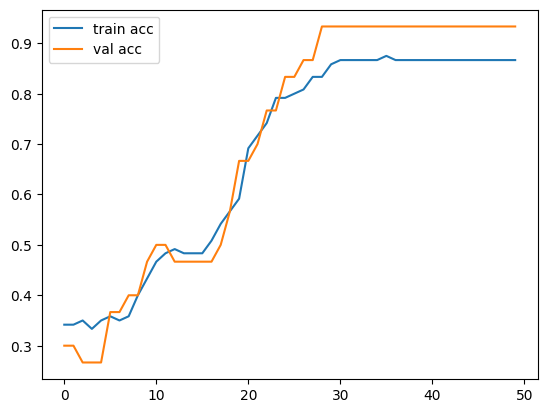

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Normalize
synonym_for_scaler = StandardScaler()
X = synonym_for_scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build ANN
model = Sequential([
    Dense(10, activation='relu', input_shape=(4,)),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

# Plot
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.show()

## Regression ANN using Boston Housing Dataset

In [ ]:
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.losses import MeanSquaredError

# Load dataset
data = load_boston()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Build regression ANN
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

# Predicted vs Actual
y_pred = model.predict(X_test)
plt.scatter(y_test, y_pred); plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.show()

## LSTM Model Definition

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# NOTE: You need to define 'timesteps' and 'features' based on your time series data.
# For example:
# timesteps = 10 # Number of time steps in each input sequence
# features = 1   # Number of features per time step

# Placeholder values for demonstration. Replace with your actual values.
timesteps = 10
features = 1

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(timesteps, features)),
    LSTM(50),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Task 6: Ensemble Learning with ANNs

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model 1 with 32 neurons...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Training model 2 with 64 neurons...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Training model 3 with 128 neurons...


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Individual Model Accuracies: [0.956140350877193, 0.9736842105263158, 0.9736842105263158]
Ensemble Accuracy: 0.9736842105263158
Individual Model AUCs: [np.float64(0.9977071732721913), np.float64(0.9980347199475925), np.float64(0.9983622666229938)]
Ensemble AUC: 0.9742875859810023


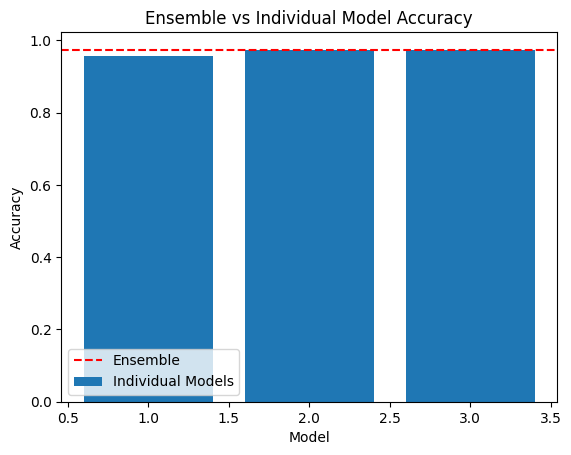

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to build ANN model
def build_model(neurons=64):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X.shape[1],)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train multiple models with different architectures
models = [
    build_model(32),
    build_model(64),
    build_model(128)
]

predictions = []
for i, m in enumerate(models):
    print(f"Training model {i+1} with {m.layers[0].units} neurons...")
    m.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
    preds = m.predict(X_test)
    predictions.append(preds)

# Bagging: average predictions
ensemble_pred = np.mean(predictions, axis=0).round()

# Evaluate performance
individual_acc = [accuracy_score(y_test, (preds > 0.5).astype(int)) for preds in predictions]
ensemble_acc = accuracy_score(y_test, ensemble_pred.astype(int))

print("Individual Model Accuracies:", individual_acc)
print("Ensemble Accuracy:", ensemble_acc)

# ROC-AUC comparison
individual_auc = [roc_auc_score(y_test, preds) for preds in predictions]
ensemble_auc = roc_auc_score(y_test, ensemble_pred)

print("Individual Model AUCs:", individual_auc)
print("Ensemble AUC:", ensemble_auc)

# Visualization
plt.bar(range(1, len(individual_acc)+1), individual_acc, label="Individual Models")
plt.axhline(y=ensemble_acc, color='r', linestyle='--', label="Ensemble")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Ensemble vs Individual Model Accuracy")
plt.show()